In [1]:
import sys
sys.path.append("/userdata/jgauthier/projects/EMU_data_collection/src/python")
sys.path.append("src")

In [11]:
import os
from pathlib import Path

import h5py
import pandas as pd

In [13]:
%load_ext autoreload
%autoreload 2

In [38]:
from neuralynx_to_mne import epoch_ecog_mne
from viz import plot_epochs

In [4]:
# =============================================================================
# CONFIGURATION - Update these parameters for your analysis
# =============================================================================

# Patient and Block Configuration
PATIENT = "EC347"
NL_BLOCK = "B16"  # block name of the raw Neuralynx recording
BLOCK = "default"  # block name of the preprocessed block directory. Set to `default` will default to using `NL_BLOCK`.
MULTIPLE_RECORDINGS = False  # whether there are multiple recordings within this single Neuralynx `BLOCK`. Default to `False`.

if BLOCK == "default":
    BLOCK = NL_BLOCK

############
### If there are multiple recordings in a single Neuralynx "block", `BLOCK_IDX` indicates which one to preprocess. 
### Will use recording times from the events `.nev` file to select the chunk of raw data to use from the full recording.
### If this is a single block, set to `None`.
############
BLOCK_IDX = None

TASK = "dot-prediction"

# Path Configuration
RAW_ROOT = f"/data_store1/human/Neuralynx/{PATIENT}/{PATIENT}_{NL_BLOCK}"
SESSION_SUBDIR = os.listdir(RAW_ROOT)[0] ## need manual check
PREPROC_ROOT = f"/data_store1/human/Neuralynx_preproc/{PATIENT}/{PATIENT}_{BLOCK}"

# Processing Parameters
GRID_N_CH = 74
RUN_CAR = False ## run car or not
CAR_BSIZE = 16
DS_HZ = 1000 # Intermediate sampling rate (in Hz).
FINAL_HZ = 100
SUFFIX = ""  ## example: "0005"
EVENT_SUFFIX = ""  ## suffix for the `Events_XXXX.nev` file

# Optional: 3D Visualization (set to None to skip)
ANAT_ROOT = None  # or None

# ERP Analysis Parameters

# For theta
# BUFFER_BEFORE = 300   # samples before stimulus onset
# BUFFER_AFTER = 100    # samples after stimulus offset

# For HGA
BUFFER_BEFORE = 300   # samples before stimulus onset
BUFFER_AFTER = 150    # samples after stimulus offset

# Display configuration
print("🔧 Configuration:")
print(f"   Patient: {PATIENT}")
print(f"   Block: {BLOCK}")
print(f"   Task: {TASK}")
print(f"   Raw data: {RAW_ROOT}")
print(f"   Preprocessing: {PREPROC_ROOT}")
print(f"   Grid channels: {GRID_N_CH}")
print(f"   Final sampling rate: {FINAL_HZ} Hz")
print(f"   Anatomy data: {ANAT_ROOT if ANAT_ROOT else 'Not provided'}")


🔧 Configuration:
   Patient: EC347
   Block: B16
   Task: dot-prediction
   Raw data: /data_store1/human/Neuralynx/EC347/EC347_B16
   Preprocessing: /data_store1/human/Neuralynx_preproc/EC347/EC347_B16
   Grid channels: 74
   Final sampling rate: 100 Hz
   Anatomy data: Not provided


In [6]:
ecog_output_dir = os.path.join(PREPROC_ROOT, "ECoG_preproc")

In [9]:
# Load the final preprocessed data for verification
with h5py.File(Path(ecog_output_dir, f"{PATIENT}_{BLOCK}_100hz_nocar_Hilb.h5"), 'r') as hf:
    ecog_data = hf['ds_X_abs'][:]
    freq_centers = hf.attrs['filter_center']
    freq_sigmas = hf.attrs['filter_sigma']
    
print(f"   Frequency bands: {len(freq_centers)} bands")
print(f"   Frequency range: {freq_centers[0]:.1f} - {freq_centers[-1]:.1f} Hz")
print(f"   Data shape: [frequencies, channels, time] = {ecog_data.shape}")


   Frequency bands: 40 bands
   Frequency range: 4.1 - 193.5 Hz
   Data shape: [frequencies, channels, time] = (40, 74, 128999)


In [12]:
error_contrast_path = os.path.join(PREPROC_ROOT, "audio_preproc", TASK, f"{PATIENT}_{BLOCK}_{TASK}_previous-error-scale.csv")
error_contrast_data = pd.read_csv(error_contrast_path)

In [33]:
ret = epoch_ecog_mne(
    ecog_data=ecog_data,
    start_times=error_contrast_data.stimulus_start,
    end_times=error_contrast_data.stimulus_stop,
    baseline_times=error_contrast_data[['baseline_start', 'baseline_stop']].to_numpy(),
    frequency_bands=["theta", "hga"],
    freq_centers=freq_centers,
    epoch_metadata=error_contrast_data,
    final_hz=FINAL_HZ,
    buffer_before=BUFFER_BEFORE,
    buffer_after=BUFFER_AFTER
)

/userdata/jgauthier/projects/dot-prediction/src/neuralynx_to_mne.py:171: RuntimeWarning: Mean of empty slice
  epochs_list = []


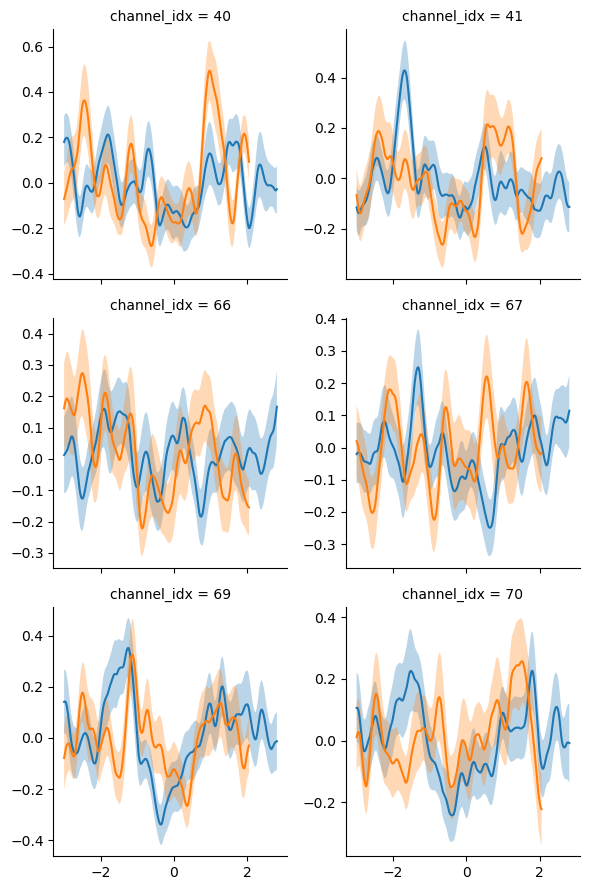

In [62]:
plot_epochs(ret[0], [40, 41, 66, 67, 69, 70],
            {"low": "label == 'low' and l2_error_previous_bin == 0",
             "high": "label == 'high' and l2_error_previous_bin == 4"})